# Course Project: Optimizing Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score

In this course project, you will build logistic regression models using "Cell2Cell", a telecom company churn prediction data set. You will build many variants, each one with a different value of the $C$ hyperparameter, which governs the amount of regularization used. Regularization is a process where we add a "penalty" to the original log loss function. This penalty is a function of the magnitudes of the weights learned in the Logistic Regression. The following shows the regularized log loss using what is called "L2" regularization.<br><br> 

<center>$Regularized \ LogLoss = -\frac{1}{N} \sum\limits_{i=1}^N (y_ilog(P_i)+(1-y_i)log(1-P_i))+\frac{1}{C} \sum\limits_{j=1}^m w_j^2$</center><br><br>



With L2 regularization, the penalty is the sum of the squares of the weights scaled by a constant $1/C$. When the hyperparameter $C$ is large, we reduce the weight of the penalty, which results in less regularization. You will build Logistic regressions with different values of $C$ and will check how this impacts the log loss.

In this course project, you will implement the following steps:

1. Load the "cell2celltrain" data set.
2. Create labeled examples containing numerical features only.
3. Split the data into training and test data sets.
4. Fit a Logistic Regression classifier using scikit-learn and evaluate the log loss and accuracy of the predictions.
5. Fit multiple Logistic Regression classifiers with different values of the regularization hyperparameter $C$ and plot the resulting log loss and accuracy.

## Part 1. Load the Data Set

We will work with the "cell2celltrain" data set.

In [2]:
# Do not remove or edit the line below:
filename = os.path.join(os.getcwd(), "data", "cell2celltrain.csv")

**Task**: Load the data and save it to DataFrame `df`.

In [3]:
# YOUR CODE HERE
## Cell 01 
df = pd.read_csv(filename, header=0)

## Part 2: Create Labeled Examples from the Data Set 

To implement a Logistic Regression model, we must use only the numeric columns. 


<b>Task</b>: Use the Pandas DataFrame <code>select_dtypes()</code> method to obtain all of names of columns that have a dtype of "float64." Save the result to a list named `feature_list`. 

In [4]:
# YOUR CODE HERE
## Cell 02 TO DO
## Goal: feature_list = names of all columns dtype = float64
## code note: similiar to Lostistic regression lab

feature_list = list(df.select_dtypes(include=['float64']).columns)

print(feature_list)  # I added this, not required, but wanted to see (And make sure code was working)

## output ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'RetentionCalls', 'RetentionOffersAccepted', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'AdjustmentsToCreditRating', 'HandsetPrice']

['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'RetentionCalls', 'RetentionOffersAccepted', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'AdjustmentsToCreditRating', 'HandsetPrice']


<b>Task</b>: Create labeled examples from DataFrame `df`.

In the code cell below carry out the following steps:

* Get the `Churn` column from DataFrame `df` and assign it to the variable `y`. This will be our label. The label will be either True or False.
* Get the columns listed in `feature_list`from DataFrame `df` and assign them to the variable `X`. These will be our features. 

You should have 51047 labeled examples. Each example contains 35 features and one label (`Churn`).

In [5]:
# YOUR CODE HERE
## Cell 02
## Goal: colums listed in feature_list from df are X.
## code note: similiar to Lostistic regression lab

y = df['Churn']
X = df[feature_list]


print("Number of examples: " + str(X.shape[0]))
print("\nNumber of Features:" + str(X.shape[1]))
print(str(list(X.columns)))

## Output: (yes, looks correct) 

## Number of examples: 51047

## Number of Features:35
## ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'RetentionCalls', 'RetentionOffersAccepted', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'AdjustmentsToCreditRating', 'HandsetPrice']


Number of examples: 51047

Number of Features:35
['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'RetentionCalls', 'RetentionOffersAccepted', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'AdjustmentsToCreditRating', 'HandsetPrice']


## Part 3: Create Training and Test Data Sets

<b>Task</b>: In the code cell below create training and test data sets out of the labeled examples. 

1. Use scikit-learn's `train_test_split()` method to create the data sets.

2. Specify:
    * A test set that is 33 percent (.33) of the size of the data set.
    * A seed value of '1234'. 
    


In [6]:
# YOUR CODE HERE
## Cell 03
## Goal: .33, and random_state_seed = 1234, assign outputs
# Source notes: from 463 course project part 4,
## code note: similiar to Lostistic regression lab


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1234)



Check that the dimensions of the training and test data sets are what you expected:

In [7]:
print(X_train.shape)
print(X_test.shape)

## Output, yep looks good

## (34201, 35)
## (16846, 35)

(34201, 35)
(16846, 35)


## Part 4. Fit a Logistic Regression Classifier and Evaluate the Model

The code cell below contains a shell of a function named `train_test_LR()`. This function will train a Logistic Regression model on the training data, test the resulting model on the test data, and compute and return (1) the log loss of the resulting probability predictions on the test data and (2) the accuracy score of the resulting predicted class labels on the test data. 

Inspect the function definition `train_test_LR(X_train, X_test, y_train, y_test, c=1)`. The function expects the test and train datasets as well as a value for hyperparameter $C$. Note that we supplied the value of 1 for $C$ by default.

You will use the scikit-learn ```LogisticRegression``` class. Use `LogisticRegression()` to create a model object, and assign the result to the variable ```model```. You will provide the arguments `C=c`.

<b>Task:</b> Complete the function to make it work.


In [16]:
def train_test_LR(X_train, y_train, X_test, y_test, c=1):
    '''
    Fit a Linear Regression classifier to the training data X_train, y_train.
    Return the loss and accuracy of resulting predictions on the test set.
    Parameters:
        C = Factor that controls how much regularization is applied to the model.
    '''
     # 1. Create the  scikit-learn LogisticRegression model object below and assign to variable 'model'
      # YOUR CODE HERE
    ## Cell 04.01
    ## Goal: model = LogisticRegression() from scikitlearn, argument C=c
    ## Code source notes: M2 05 Video Logistic Regression (also scikit-learn documendation)
    
    model = LogisticRegression(C=c)   #check documentation
    
  
    # 2. Fit the model to the training data below
     # YOUR CODE HERE
    ## Cell 04.02
    ## Goal: 
    ## Code source notes: M2 05 Video Logistic Regression (also scikit-learn documendation)
    
    model.fit(X_train, y_train)
    
    
    # 3. Make predictions on the test data using the predict_proba() method and assign the result to the 
    # variable 'probability_predictions' below
     # YOUR CODE HERE
    ## Cell 04.03
    ## Code source notes: M2 05 Video Logistic Regression (also scikit-learn documendation)
    
    probability_predictions = model.predict_proba(X_test)
        
  
    # 4. Compute the log loss on 'probability_predictions' and save the result to the variable 'l_loss' below
     # YOUR CODE HERE
    ## Cell 04.04
    
    l_loss = log_loss(y_test, probability_predictions)
        
    # 5. Make predictions on the test data using the predict() method and assign the result to the 
    # variable 'class_label_predictions' below
     # YOUR CODE HERE
    ## Cell 04.05
    ## code notes: from Logistic Regression lab 
    
    class_label_predictions = model.predict(X_test)
        
        
        
    # 6. Compute the accuracy score on 'class_label_predictions' and save the result to the variable 'acc_score' below
     # YOUR CODE HERE
    ## Cell 04.06
        ## code notes: from Logistic Regression lab 
    
    acc_score = accuracy_score(y_test, class_label_predictions)
        
    
    
    return l_loss, acc_score


###  Train a Model and Analyze the Results

The code cell below uses your function `train_test_LR()` to train one Logistic Regression classifier with the default value of hyperparameter C (`c=1`) and evaluates the model's predictions on the test data. Run the code cell and inspect the resulting loss and accuracy.

In [17]:
loss, acc = train_test_LR(X_train, y_train, X_test, y_test)
print('Log loss: ' + str(loss))
print('Accuracy: ' + str(acc))

## Output, looks like code worked, looks accurate, haha I would def round that as displayed but 
## maybe diff btwn this and further iterations will be v low so need high accuracy?
## Log loss: 0.5878612157234173
## Accuracy: 0.7097827377418972

Log loss: 0.5878612157234173
Accuracy: 0.7097827377418972


## Part 5. Train on Different Hyperparameter Values and Analyze the Results

Now we will adjust the $C$ regularization hyperparameter to check its impact on the model's log loss. In the scikit-learn ``LogisticRegression`` class documentation, parameter `C` stands for the inverse of regularization strength. Smaller values specify stronger regularization.<br>

The code cell below creates a list `cs` of twenty values of $C$.  Every item in the list has a value $10^i$ for every integer $i$ in the output of `range(-10,10)`. Run the code cell below and inspect the different values of $C$.

In [10]:
cs = [10**i for i in range(-10,10)]
cs

## Output
## [1e-10,
 ## 1e-09,
 ## 1e-08,
 ## 1e-07,
 ## 1e-06,
 ## 1e-05,
 ## 0.0001,
 ## 0.001,
 ## 0.01,
 ## 0.1,
 ## 1,
 ## 10,
 ## 100,
 ## 1000,
 ## 10000,
 ## 100000,
 ## 1000000,
 ## 10000000,
 ## 100000000,
 ## 1000000000]

[1e-10,
 1e-09,
 1e-08,
 1e-07,
 1e-06,
 1e-05,
 0.0001,
 0.001,
 0.01,
 0.1,
 1,
 10,
 100,
 1000,
 10000,
 100000,
 1000000,
 10000000,
 100000000,
 1000000000]

Now we want to train and evaluate a different Logistic Regression model for every value of $C$ in the list `cs`. 

<b>Task</b>: In the code cell below, follow these steps:

1. Initialize an empty Python list called `ll_cs`. This is where we will store the log loss for every model.
2. Initialize an empty Python list called `acc_cs`. This is where we will store the accuracy score for every model.
2. Write a loop that iterates over list `cs`. Within the loop, do the following:
3. Call your function `train_test_LR()` with the training and test data and with the current value of $C$.
4. The function `train_test_LR()` returns two items. 
    1. Append the first item to the list `ll_cs`.
    2. Append the second item to the list `acc_cs`.


In [22]:
# YOUR CODE HERE
## Cell 05 Working on this one zzz
## Goal notes: reminds me of courses for my graduate certificate in 
## Computer Modeling and Simulation from the Systems Science Program at Portland State University, 
## iterating through a model, with variously ranged inputs, more precisely Monte Carlo or discrete systems simulation
## Goal overall: iteratively train a regression model thru each value of C on the list cs 
##                (see above output, eg 10, 100, 1000)

## Step 1/5) ll_cs = initalize empty list , which will store log loss for every model

## Step 2/5) acc_cs = initialize empty list, which store the accuracy score for every model

## Step 3/5) loop: iterates over list cs, wn loop steps 4 and 5
## Step 4/5) wn loop: call function train_test_LR() with the training and test data and with the current value of C
    ## this much indent
    ## Step 4/5) wn loop: call function train_test_LR() with the training and test data and with the current value of C
    ## from above provided code on function 
    ## train_test_LR(X_train, y_train, X_test, y_test, c=1):
    ## Fit a Linear Regression classifier to the training data X_train, y_train.
    ## Return the loss and accuracy of resulting predictions on the test set.
    ## Parameters:
    ##    C = Factor that controls how much regularization is applied to the model.

    ## Step 5/5) wn loop, also parts 5a and 5b: The function train_test_LR() returns two items

    ## Step 5/5) wn loop, also parts 5a and 5b: The function train_test_LR() returns two items
        
    ## Step 5a)  append first item (1st) to the list ll_cs   ... log loss

    ## Step 5a)  append first item (1st) to the list ll_cs   ... log loss = l_loss

    ## Step 5b)  append second (2nd) item to the list acc_cs ... accuracy score

    ## Step 5b)  append second (2nd) item to the list acc_cs ... accuracy score = acc_score

    
ll_cs = []  # Step 1: list to store log loss output for each iteration

acc_cs = [] # Step 2: list to store accuracy score for each iteration

for i in cs: # Step 3: not sure what var is in cs to call, i is generic? will see
    
    loss, acc = train_test_LR(X_train, y_train, X_test, y_test, c=i)   # Step 4: same as function above but c = i
    
    ll_cs.append(loss)  # Step 5a: var name from function above, log loss for current iteration
    
    acc_cs.append(acc)  # Step 5b: var name from function above, accuracy score for current iteration 
    
  
    
## current problem: loop structure is not calling function so not pulling output into final append tables, 
## doesn't know what vars are eg NameError: name 'acc_score' is not defined
## indents may not be correct or maybe need colon or something, look into other examples of 
## for loop calling previously defined funtion then sending outputs to append tables

# resolution: examined "Train a Model and Analyze the Results" section of provided code for implementation, 
#    changed vars to "acc and "loss"
    

Now lets visualize the results. 

#### Plot Log Loss

Execute the code below to plot the resulting log loss for every value of hyperparameter $C$. Take some time to study the code, which uses `seaborn` to build the main plot and `matplotlib` to customize it.

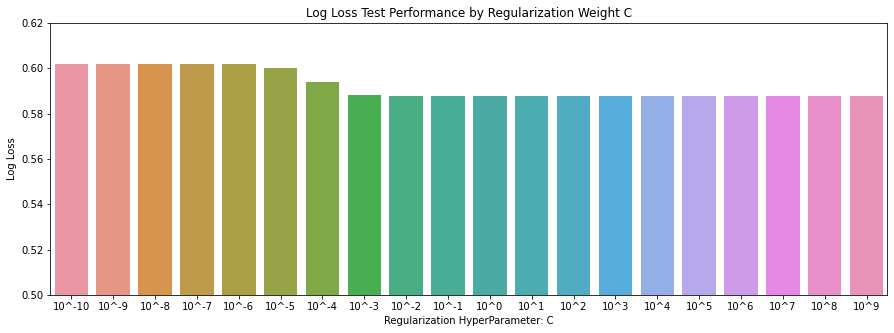

In [23]:
plt.figure(figsize=(15,5)) 

ax = sns.barplot(x=cs, y=ll_cs)
g = ax.set_xticklabels([f'10^{i}' for i in range(-10,10)])
ax.set_xlabel('Regularization HyperParameter: C')
ax.set_ylabel('Log Loss')
ax.set_ylim([0.5, 0.62])
g = plt.title('Log Loss Test Performance by Regularization Weight C')

<b>Analysis</b>: Which value of $C$ yields the best results, in terms of loss?

<Double click this Markdown cell to make it editable, and record your findings here.>

Since it is better to have low value of log loss, when the hyperparameter = 10^(-3), the log loss is the lowest it will get for the lowest value of the hyperparameter. Although since the low value of the log loss is consistently low (good) from 10^(-3) to 10^9, so any of the values for the C within the range (10^(-3) : 10^9 ) inclusive provide the lowest (best) log loss values for the model.

#### Plot Accuracy

Execute the code below below to plot the resulting accuracy for every value of hyperparameter $C$.

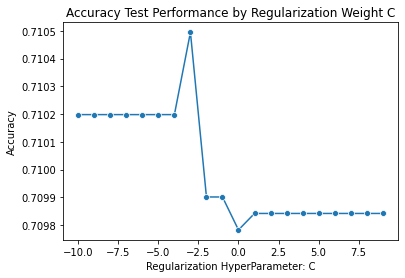

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)
x = np.log10(cs)

sns.lineplot(x=x, y=acc_cs, marker='o')

plt.title("Accuracy Test Performance by Regularization Weight C")
plt.xlabel("Regularization HyperParameter: C")
plt.ylabel("Accuracy")
plt.show()

<b>Analysis</b>: Which value of $C$ yields the best results, in terms of accuracy?

<Double click this Markdown cell to make it editable, and record your findings here.>

The dot and line graph clearly shows that highest accuracy value (0.7105) is at regularized value for hyperparameter C = -2.5, so that is the value of C that yields the best results in terms of accuracy. I believe (but would like more practice interepreting) that this translated onto the above column chart as C = 10^-2.5, which in decimals is 0.00316227766

Previous analysis showed that the best for log loss hyperparameters were between inclusive 0.001 to 1000000000. The regularization value for these would be centered around 0, 20 values of C, so first half, lower values, are negative, others are positive. break is between 10^-1 and 10^0, so between .1 and 1, so then -2.5, which in decimals is 0.00316227766, shown in the graph is between 10^-2 and 10^-3, which is equal to 0.01 to 0.1, this range is included in the above analysist for the best (lowest) log loss hyperparameter value range of (0.001 to 1000000000). This is a cross check also to see if both answers make sense with the larger analysis and modeling questions. 

